
===== METRICS TABLE =====
                     Accuracy  Precision    Recall        F1
Logistic Regression  0.753247   0.666667  0.618182  0.641509
Decision Tree        0.727273   0.591549  0.763636  0.666667


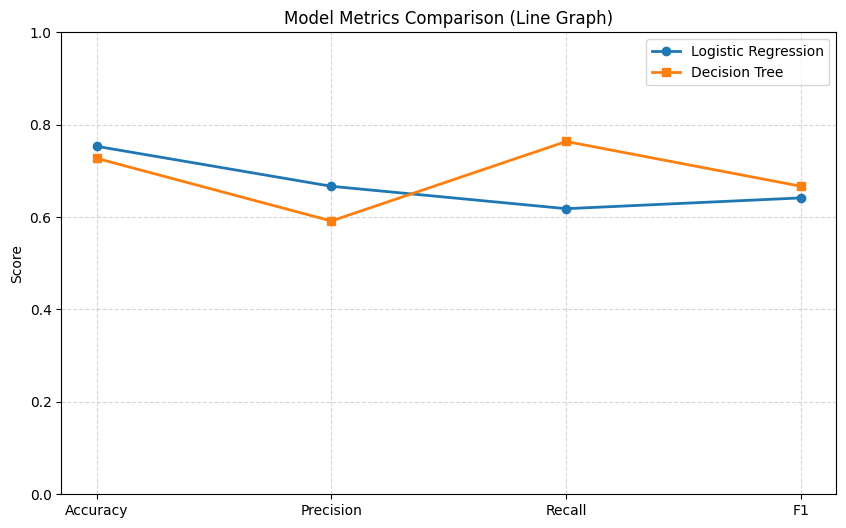

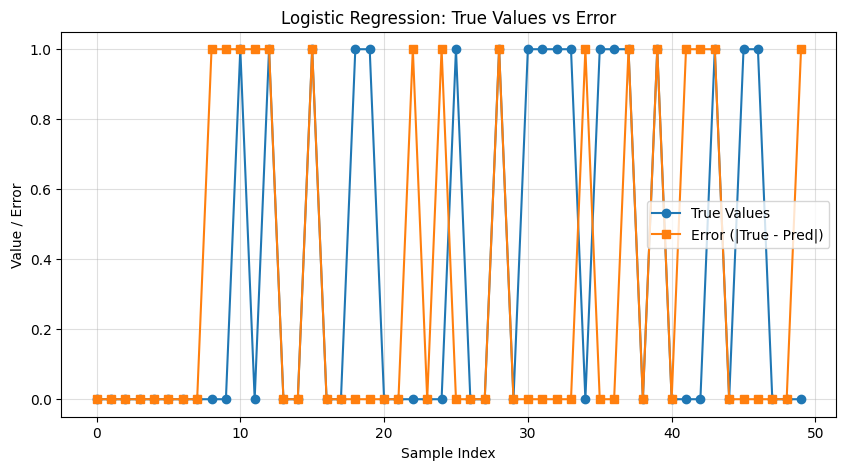

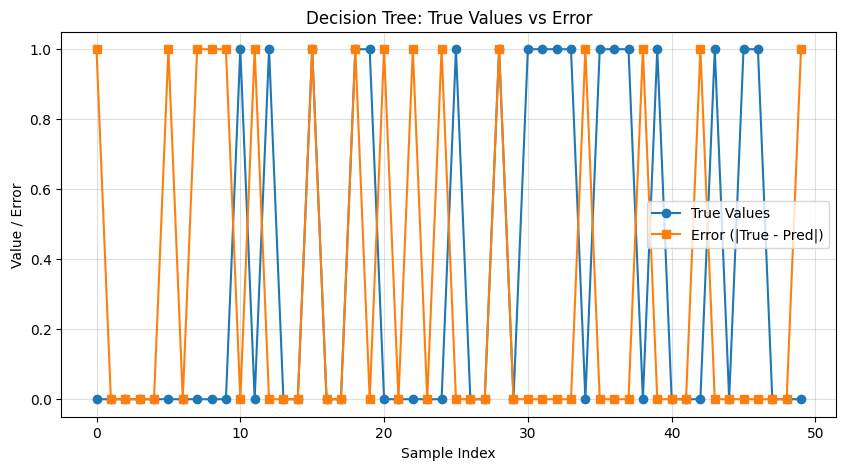

Logistic Regression Confusion Matrix:
 [[82 17]
 [21 34]]

Decision Tree Confusion Matrix:
 [[70 29]
 [13 42]]


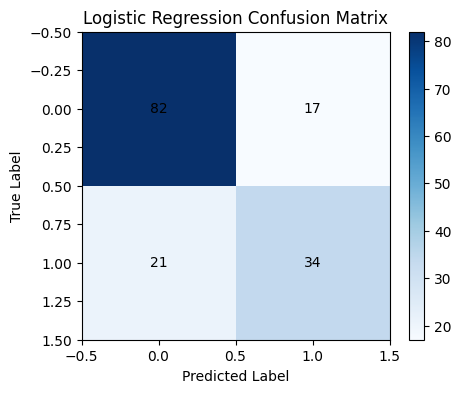

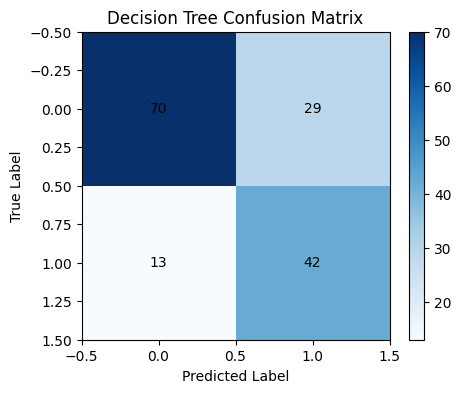

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ==========================================
# Step 1: Load Dataset
# ==========================================

df = pd.read_csv("diabetes.csv")

# ==========================================
# Step 2: Data Cleaning (Handle Invalid Zeros)
# ==========================================

cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

# ==========================================
# Step 3: Feature / Target Split
# ==========================================

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# ==========================================
# Step 4: Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# Step 5: Feature Scaling (for Logistic Regression)
# ==========================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# Step 6: Define Models
# ==========================================

log_model = LogisticRegression(max_iter=1000)
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# ==========================================
# Step 7: Train Models
# ==========================================

log_model.fit(X_train_scaled, y_train)
tree_model.fit(X_train, y_train)

# ==========================================
# Step 8: Predictions
# ==========================================

log_pred = log_model.predict(X_test_scaled)
tree_pred = tree_model.predict(X_test)

# ==========================================
# Step 9: Evaluation Metrics Function
# ==========================================

def compute_metrics(y_true, y_pred):
    """Return classification metrics as dictionary"""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

log_metrics = compute_metrics(y_test, log_pred)
tree_metrics = compute_metrics(y_test, tree_pred)

# ==========================================
# Step 10: Print Baseline Results
# ==========================================

results_df = pd.DataFrame([
    log_metrics,
    tree_metrics
], index=["Logistic Regression", "Decision Tree"])

print("\n===== METRICS TABLE =====")
print(results_df)
# ==========================================
# Step 11: Metric Visualization Function
# ==========================================

metrics = ["Accuracy", "Precision", "Recall", "F1"]

log_values = [log_metrics[m] for m in metrics]
tree_values = [tree_metrics[m] for m in metrics]

plt.figure(figsize=(10,6))

plt.plot(metrics, log_values, marker='o', linewidth=2, label="Logistic Regression")
plt.plot(metrics, tree_values, marker='s', linewidth=2, label="Decision Tree")

plt.title("Model Metrics Comparison (Line Graph)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.show()
# ==========================================
# Plot 2D Model Fitting (Decision Boundaries)
# ==========================================

plt.figure(figsize=(10,5))

samples = np.arange(50)

log_error = np.abs(y_test.values[:50] - log_pred[:50])

plt.plot(samples, y_test.values[:50], marker='o', label="True Values")
plt.plot(samples, log_error, marker='s', label="Error (|True - Pred|)")

plt.title("Logistic Regression: True Values vs Error")
plt.xlabel("Sample Index")
plt.ylabel("Value / Error")
plt.legend()
plt.grid(True, alpha=0.4)

plt.show()
plt.figure(figsize=(10,5))

samples = np.arange(50)

tree_error = np.abs(y_test.values[:50] - tree_pred[:50])

plt.plot(samples, y_test.values[:50], marker='o', label="True Values")
plt.plot(samples, tree_error, marker='s', label="Error (|True - Pred|)")

plt.title("Decision Tree: True Values vs Error")
plt.xlabel("Sample Index")
plt.ylabel("Value / Error")
plt.legend()
plt.grid(True, alpha=0.4)

plt.show()
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# Step: Confusion Matrix Calculation
# ==========================================

cm_log = confusion_matrix(y_test, log_pred)
cm_tree = confusion_matrix(y_test, tree_pred)

print("Logistic Regression Confusion Matrix:\n", cm_log)
print("\nDecision Tree Confusion Matrix:\n", cm_tree)

# ==========================================
# Step: Visualization Function
# ==========================================

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    # Add values inside boxes
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center",
                     color="black")

    plt.colorbar()
    plt.show()

# ==========================================
# Step: Plot Both Models
# ==========================================

plot_confusion_matrix(cm_log, "Logistic Regression Confusion Matrix")
plot_confusion_matrix(cm_tree, "Decision Tree Confusion Matrix")



# New Section